# Exploratory Data Analysis

Datasets:
- UCI Credit Card Default
- Telco Customer Churn

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Paths relative to the notebook (notebooks/ -> one level up -> Data/Raw/)
RAW_DIR     = os.path.join("..", "Data", "Raw")
RESULTS_DIR = os.path.join("..", "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

## 1. Load datasets

In [2]:
df_uci   = pd.read_csv(os.path.join(RAW_DIR, "default_credit_card.csv"))
df_telco = pd.read_csv(os.path.join(RAW_DIR, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

print("UCI   shape:", df_uci.shape)
print("Telco shape:", df_telco.shape)

UCI   shape: (30000, 25)
Telco shape: (7043, 21)


## 2. Clean Telco — drop rows with missing TotalCharges

In [3]:
# TotalCharges arrives as object (blank strings); coerce to numeric first
df_telco["TotalCharges"] = pd.to_numeric(df_telco["TotalCharges"], errors="coerce")

missing_before = df_telco["TotalCharges"].isna().sum()
print(f"Rows with missing TotalCharges before drop: {missing_before}")

df_telco_clean = df_telco.dropna(subset=["TotalCharges"]).reset_index(drop=True)
print(f"Telco clean shape: {df_telco_clean.shape}")

telco_clean_path = os.path.join(RAW_DIR, "telco_clean.csv")
df_telco_clean.to_csv(telco_clean_path, index=False)
print(f"Saved -> {telco_clean_path}")

Rows with missing TotalCharges before drop: 11
Telco clean shape: (7032, 21)
Saved -> ..\Data\Raw\telco_clean.csv


## 3. Correlation heatmaps

### 3a. UCI Credit Card Default

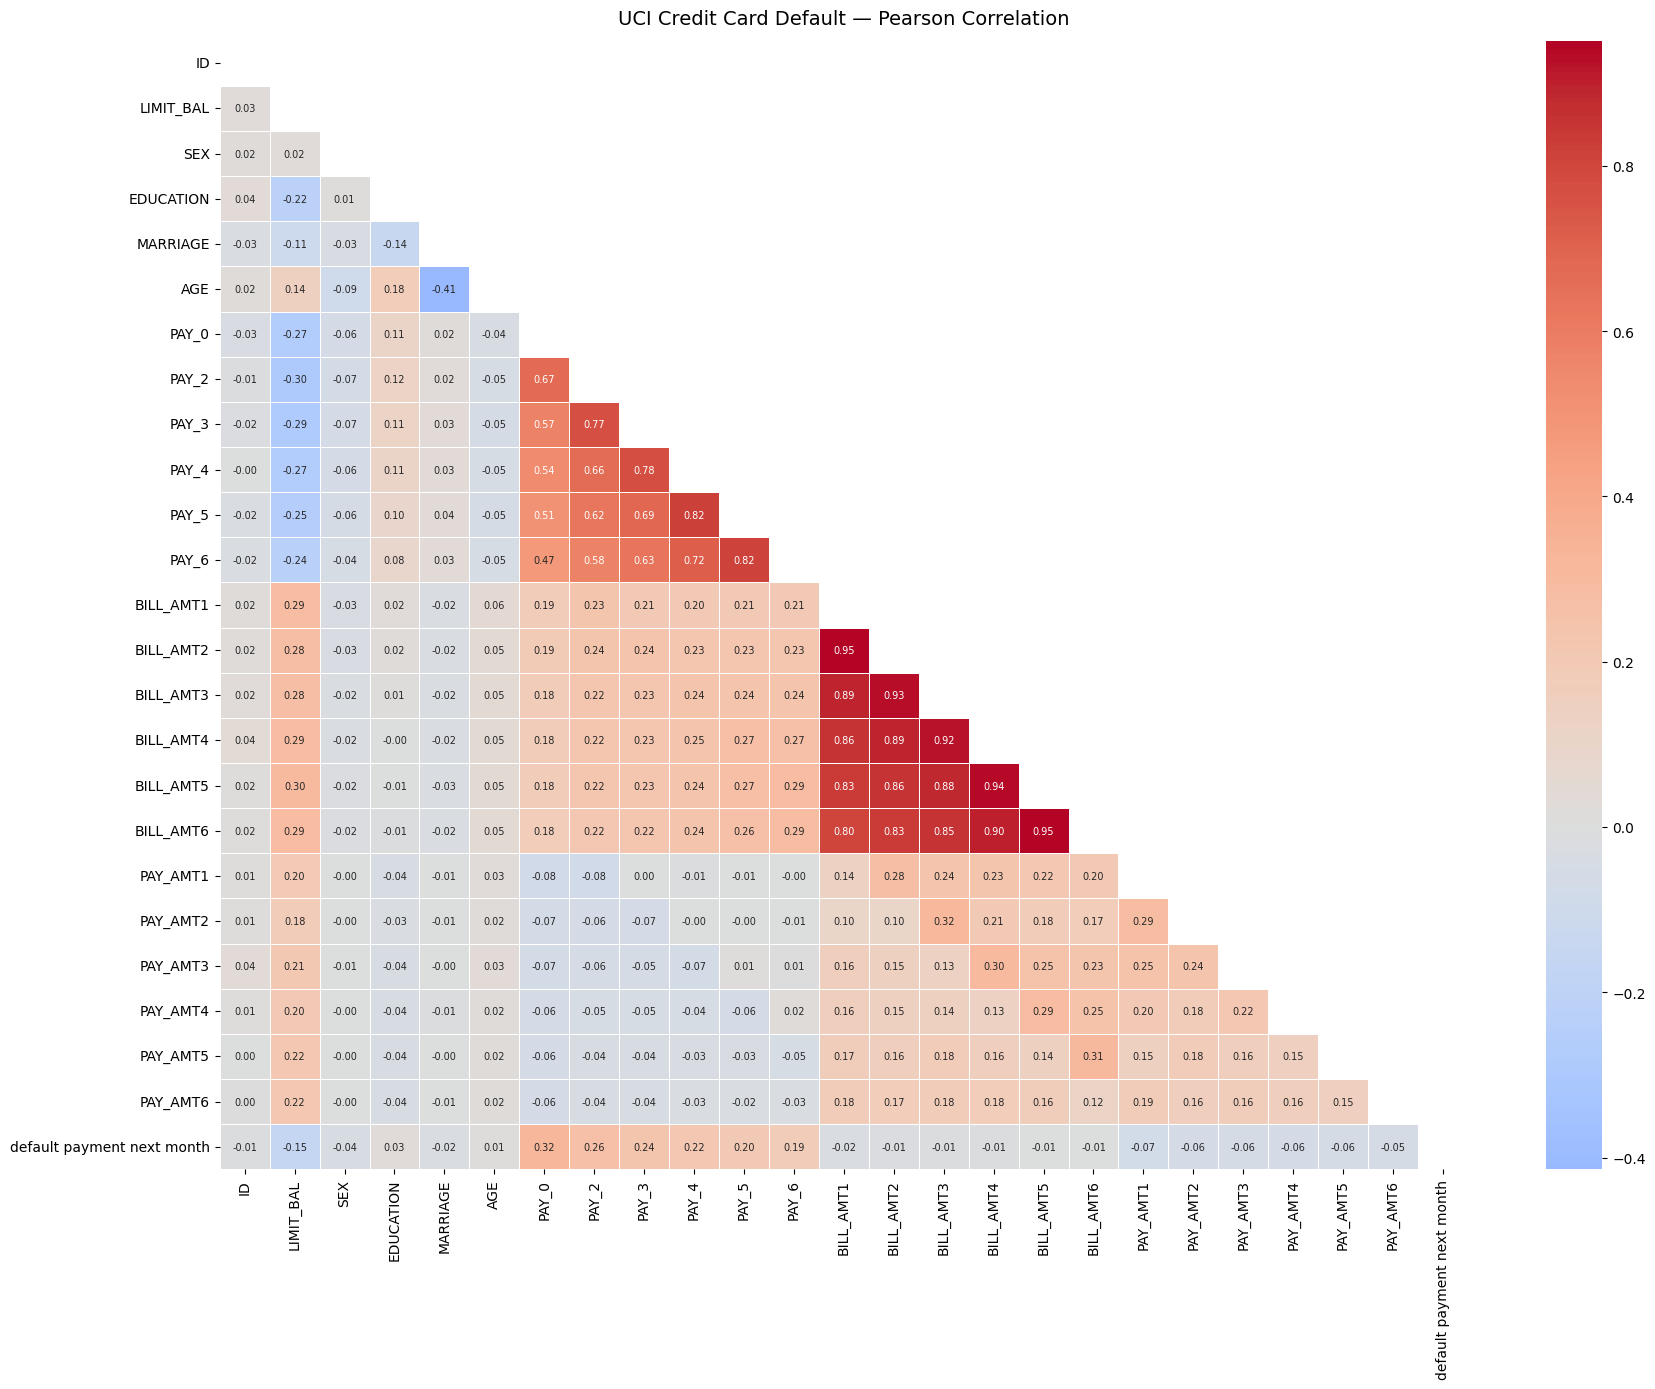

Saved -> ..\results\uci_correlation_heatmap.png


In [4]:
num_uci  = df_uci.select_dtypes(include=[np.number])
corr_uci = num_uci.corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_uci, dtype=bool))   # show lower triangle only
sns.heatmap(
    corr_uci,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    annot_kws={"size": 7},
    ax=ax
)
ax.set_title("UCI Credit Card Default — Pearson Correlation", fontsize=14, pad=12)
plt.tight_layout()

uci_heatmap_path = os.path.join(RESULTS_DIR, "uci_correlation_heatmap.png")
fig.savefig(uci_heatmap_path, dpi=150)
plt.show()
print(f"Saved -> {uci_heatmap_path}")

### 3b. Telco Customer Churn

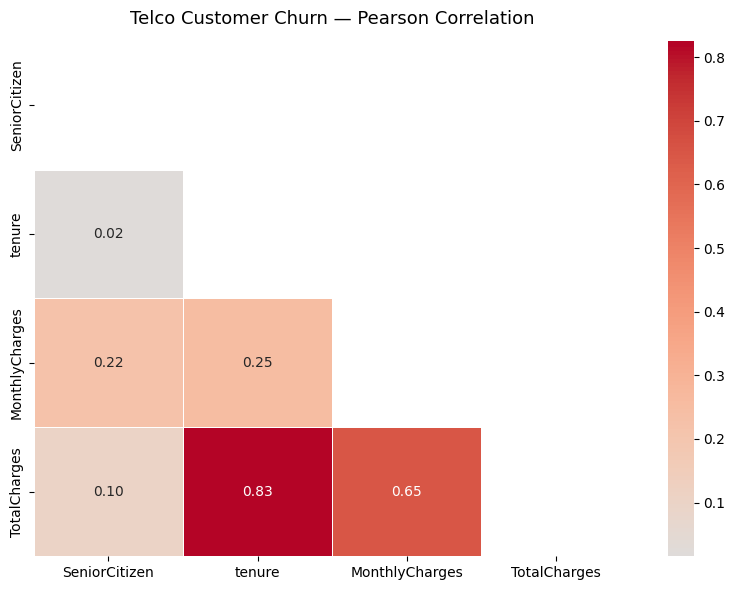

Saved -> ..\results\telco_correlation_heatmap.png


In [5]:
num_telco  = df_telco_clean.select_dtypes(include=[np.number])
corr_telco = num_telco.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_telco, dtype=bool))
sns.heatmap(
    corr_telco,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Telco Customer Churn — Pearson Correlation", fontsize=13, pad=12)
plt.tight_layout()

telco_heatmap_path = os.path.join(RESULTS_DIR, "telco_correlation_heatmap.png")
fig.savefig(telco_heatmap_path, dpi=150)
plt.show()
print(f"Saved -> {telco_heatmap_path}")

## 4. Telco — categorical columns and their unique values

In [6]:
cat_cols = df_telco_clean.select_dtypes(include=["object"]).columns.tolist()
print(f"Categorical columns ({len(cat_cols)} total):\n")
for col in cat_cols:
    uniq = sorted(df_telco_clean[col].dropna().unique().tolist())
    print(f"  {col} ({len(uniq)} unique): {uniq}")

Categorical columns (17 total):

  customerID (7032 unique): ['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS', '0017-DINOC', '0017-IUDMW', '0018-NYROU', '0019-EFAEP', '0019-GFNTW', '0020-INWCK', '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL', '0023-UYUPN', '0023-XUOPT', '0027-KWYKW', '0030-FNXPP', '0031-PVLZI', '0032-PGELS', '0036-IHMOT', '0040-HALCW', '0042-JVWOJ', '0042-RLHYP', '0048-LUMLS', '0048-PIHNL', '0052-DCKON', '0052-YNYOT', '0056-EPFBG', '0057-QBUQH', '0058-EVZWM', '0060-FUALY', '0064-SUDOG', '0064-YIJGF', '0067-DKWBL', '0068-FIGTF', '0071-NDAFP', '0074-HDKDG', '0076-LVEPS', '0078-XZMHT', '0080-EMYVY', '0080-OROZO', '0082-LDZUE', '0082-OQIQY', '0083-PIVIK', '0089-IIQKO', '0093-EXYQL', '0093-XWZFY', '0094-OIFMO', '0096-BXERS', '0096-FCPUF', '0098-BOWSO', '0100-DUVFC', '0103-CSITQ', '0104-PPXDV', '0106-GHRQR', '0106-UGRDO', '0107-WESLM', '0107-YHINA', '0111-KLBQG', '0112-QAWRZ', 